# Model Comparison

This notebook compares KNN, Logistic Regression, Decision Tree and Random Forest using exactly the same dataset, preprocessing and stratified 80/20 split. The models are evaluated on the same held-out test set.

## 1. Load data and create the common split

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns

DATA_FILE = "vijayawada_food_orders_dataset.csv"
df = pd.read_csv(DATA_FILE)
X = df.drop(columns="Cuisine_Type")
y = df["Cuisine_Type"]
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded)
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer([("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)])
print("Dataset shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Training rows:", len(X_train), "| Testing rows:", len(X_test))


Dataset shape: (10000, 8)
Missing values: 0
Duplicate rows: 0
Training rows: 8000 | Testing rows: 2000


## 2. Train the four classifiers

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "KNN": KNeighborsClassifier(n_neighbors=7, weights="distance"),
    "Logistic Regression": LogisticRegression(C=1, max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_split=2, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=75, max_depth=12, random_state=42, n_jobs=-1)
}

results=[]
for name, model in models.items():
    pipe=Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    p,r,f,_=precision_recall_fscore_support(y_test,pred,average="weighted",zero_division=0)
    results.append({"Model":name,"Accuracy":accuracy_score(y_test,pred),"Precision":p,"Recall":r,"F1_Score":f})

results_df=pd.DataFrame(results).sort_values("Accuracy",ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.6620,0.673656,0.6620,0.657560
1,Random Forest,0.6620,0.671930,0.6620,0.657973
2,Decision Tree,0.5910,0.594021,0.5910,0.586701
3,KNN,0.5345,0.537016,0.5345,0.534171


## 3. Accuracy comparison

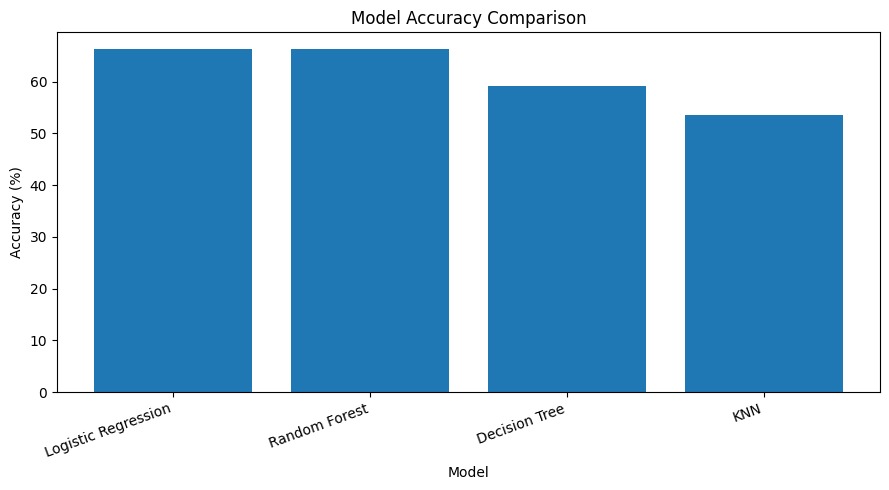

Best model: Logistic Regression
Best accuracy: 66.20%


In [3]:
plt.figure(figsize=(9,5))
plt.bar(results_df["Model"], results_df["Accuracy"]*100)
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
print("Best model:", results_df.loc[0,"Model"])
print(f"Best accuracy: {results_df.loc[0,'Accuracy']:.2%}")

## Conclusion

The best model is selected from the held-out test-set results rather than from a pre-decided accuracy claim. This comparison is fair because every classifier receives the same training/test split and the same categorical preprocessing.